<a href="https://colab.research.google.com/github/Muhammad-Waleed-Source/Pandas/blob/main/Pandas_7_Vectorized_Strings_DateTime.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

## Vectorized String Operations

In [4]:
# What are vectorized operations
a = np.array([1, 2, 3, 4])
a*4

array([ 4,  8, 12, 16])

In [5]:
# problem in vectoirzed operations in vanilla python
s = ['cat', 'mat', None, 'rat']

[i.startswith('c') for i in s] # this will give error because of None, we cannot apply startswith on None or missing data. So vanilla python is not able to handle it.

# Also this list comprehension is slow as time grows as number of list items grows

AttributeError: 'NoneType' object has no attribute 'startswith'

In [9]:
# How pandas solve this issue?
s = pd.Series(['cat', 'mat', None, 'rat'])

s.str.startswith('c') # str is string accessor

# fast and optimized

,0
0,True
1,False
2,None
3,False


In [10]:
s.str.upper()

,0
0,CAT
1,MAT
2,None
3,RAT


In [11]:
s.str.capitalize()

,0
0,Cat
1,Mat
2,None
3,Rat


In [13]:
s.str.center(10)

,0
0,cat
1,mat
2,None
3,rat


In [15]:
df = pd.read_csv('/content/titanic.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [17]:
df['Name']

,Name
0,"Braund, Mr. Owen Harris"
1,"Cumings, Mrs. John Bradley (Florence Briggs Th..."
2,"Heikkinen, Miss. Laina"
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)"
4,"Allen, Mr. William Henry"
...,...
886,"Montvila, Rev. Juozas"
887,"Graham, Miss. Margaret Edith"
888,"Johnston, Miss. Catherine Helen ""Carrie"""
889,"Behr, Mr. Karl Howell"


In [18]:
# Common functions can be applied on strings
df['Name'].str.lower()

,Name
0,"braund, mr. owen harris"
1,"cumings, mrs. john bradley (florence briggs th..."
2,"heikkinen, miss. laina"
3,"futrelle, mrs. jacques heath (lily may peel)"
4,"allen, mr. william henry"
...,...
886,"montvila, rev. juozas"
887,"graham, miss. margaret edith"
888,"johnston, miss. catherine helen ""carrie"""
889,"behr, mr. karl howell"


In [19]:
df['Name'].str.upper()

,Name
0,"BRAUND, MR. OWEN HARRIS"
1,"CUMINGS, MRS. JOHN BRADLEY (FLORENCE BRIGGS TH..."
2,"HEIKKINEN, MISS. LAINA"
3,"FUTRELLE, MRS. JACQUES HEATH (LILY MAY PEEL)"
4,"ALLEN, MR. WILLIAM HENRY"
...,...
886,"MONTVILA, REV. JUOZAS"
887,"GRAHAM, MISS. MARGARET EDITH"
888,"JOHNSTON, MISS. CATHERINE HELEN ""CARRIE"""
889,"BEHR, MR. KARL HOWELL"


In [20]:
df['Name'].str.capitalize()

,Name
0,"Braund, mr. owen harris"
1,"Cumings, mrs. john bradley (florence briggs th..."
2,"Heikkinen, miss. laina"
3,"Futrelle, mrs. jacques heath (lily may peel)"
4,"Allen, mr. william henry"
...,...
886,"Montvila, rev. juozas"
887,"Graham, miss. margaret edith"
888,"Johnston, miss. catherine helen ""carrie"""
889,"Behr, mr. karl howell"


In [21]:
df['Name'].str.title()

,Name
0,"Braund, Mr. Owen Harris"
1,"Cumings, Mrs. John Bradley (Florence Briggs Th..."
2,"Heikkinen, Miss. Laina"
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)"
4,"Allen, Mr. William Henry"
...,...
886,"Montvila, Rev. Juozas"
887,"Graham, Miss. Margaret Edith"
888,"Johnston, Miss. Catherine Helen ""Carrie"""
889,"Behr, Mr. Karl Howell"


In [27]:
# len

# finding which passenger name is lengthy
print(df['Name'].str.len().max())

print(df['Name'][df['Name'].str.len() == 82].values[0]) # masking

82
Penasco y Castellana, Mrs. Victor de Satode (Maria Josefa Perez de Soto y Vallejo)


In [28]:
# strip (remove leading and trailing spaces)
'                  waleed                 '.strip()


'waleed'

In [31]:
df['Name'].str.strip()

,Name
0,"Braund, Mr. Owen Harris"
1,"Cumings, Mrs. John Bradley (Florence Briggs Th..."
2,"Heikkinen, Miss. Laina"
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)"
4,"Allen, Mr. William Henry"
...,...
886,"Montvila, Rev. Juozas"
887,"Graham, Miss. Margaret Edith"
888,"Johnston, Miss. Catherine Helen ""Carrie"""
889,"Behr, Mr. Karl Howell"


In [36]:
# split -> get

# splitting the name based on comma.
df['Name'].str.split(',')

,Name
0,"[Braund, Mr. Owen Harris]"
1,"[Cumings, Mrs. John Bradley (Florence Briggs ..."
2,"[Heikkinen, Miss. Laina]"
3,"[Futrelle, Mrs. Jacques Heath (Lily May Peel)]"
4,"[Allen, Mr. William Henry]"
...,...
886,"[Montvila, Rev. Juozas]"
887,"[Graham, Miss. Margaret Edith]"
888,"[Johnston, Miss. Catherine Helen ""Carrie""]"
889,"[Behr, Mr. Karl Howell]"


In [40]:
# now extracting surname
df['lastname'] = df['Name'].str.split(',').str.get(0)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,lastname
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Braund
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Cumings
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Heikkinen
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Futrelle
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Allen


In [108]:
# Now again splitting to have title

df['title'] = df['Name'].str.split(',').str.get(1).str.strip().str.split('.').str.get(0)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,lastname,title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Braund,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Cumings,Mrs
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Heikkinen,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Futrelle,Mrs
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Allen,Mr


In [109]:
# Now again splitting to have name

df['firstname'] = df['Name'].str.split(',').str.get(1).str.strip().str.split('.').str.get(1)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,lastname,title,firstname
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Braund,Mr,Owen Harris
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Cumings,Mrs,John Bradley (Florence Briggs Thayer)
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Heikkinen,Miss,Laina
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Futrelle,Mrs,Jacques Heath (Lily May Peel)
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Allen,Mr,William Henry


In [110]:
# finding number of Mr, Mrs etc

df['title'].value_counts()

,count
title,
Mr,517
Miss,182
Mrs,125
Master,40
Dr,7
Rev,6
Col,2
Mlle,2
Major,2


In [111]:
df_copy = df.copy()

df_copy

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,lastname,title,firstname
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Braund,Mr,Owen Harris
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Cumings,Mrs,John Bradley (Florence Briggs Thayer)
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Heikkinen,Miss,Laina
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Futrelle,Mrs,Jacques Heath (Lily May Peel)
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Allen,Mr,William Henry
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,Montvila,Rev,Juozas
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,Graham,Miss,Margaret Edith
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,Johnston,Miss,"Catherine Helen ""Carrie"""
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,Behr,Mr,Karl Howell


In [112]:
df_copy[['title','firstname']] = df_copy['Name'].str.split(',').str.get(1).str.strip().str.split(' ', n=1, expand=True)

df_copy.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,lastname,title,firstname
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Braund,Mr.,Owen Harris
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Cumings,Mrs.,John Bradley (Florence Briggs Thayer)
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Heikkinen,Miss.,Laina
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Futrelle,Mrs.,Jacques Heath (Lily May Peel)
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Allen,Mr.,William Henry


In [113]:
# replace
# as we have Miss, Mrs and Mlle(French word for miss) we want to replace it with only Miss

df_copy['title'] = df_copy['title'].str.replace('Ms.', 'Miss.')
df_copy['title'] = df_copy['title'].str.replace('Mlle.', 'Miss.')

In [115]:
df_copy['title'].value_counts()

,count
title,
Mr.,517
Miss.,185
Mrs.,125
Master.,40
Dr.,7
Rev.,6
Major.,2
Col.,2
Don.,1


In [117]:
# filtering
# fetching details name starts with 'A'

df_copy[df_copy['firstname'].str.startswith('A')] # masking

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,lastname,title,firstname
13,14,0,3,"Andersson, Mr. Anders Johan",male,39.0,1,5,347082,31.2750,NaN,S,Andersson,Mr.,Anders Johan
22,23,1,3,"McGowan, Miss. Anna ""Annie""",female,15.0,0,0,330923,8.0292,NaN,Q,McGowan,Miss.,"Anna ""Annie"""
35,36,0,1,"Holverson, Mr. Alexander Oskar",male,42.0,1,0,113789,52.0000,NaN,S,Holverson,Mr.,Alexander Oskar
38,39,0,3,"Vander Planke, Miss. Augusta Maria",female,18.0,2,0,345764,18.0000,NaN,S,Vander Planke,Miss.,Augusta Maria
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0000,B28,NaN,Icard,Miss.,Amelie
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
842,843,1,1,"Serepeca, Miss. Augusta",female,30.0,0,0,113798,31.0000,NaN,C,Serepeca,Miss.,Augusta
845,846,0,3,"Abbing, Mr. Anthony",male,42.0,0,0,C.A. 5547,7.5500,NaN,S,Abbing,Mr.,Anthony
866,867,1,2,"Duran y More, Miss. Asuncion",female,27.0,1,0,SC/PARIS 2149,13.8583,NaN,C,Duran y More,Miss.,Asuncion
875,876,1,3,"Najib, Miss. Adele Kiamie ""Jane""",female,15.0,0,0,2667,7.2250,NaN,C,Najib,Miss.,"Adele Kiamie ""Jane"""


In [119]:
# ends with 'Z'

df_copy[df_copy['firstname'].str.endswith('A')]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,lastname,title,firstname
64,65,0,1,"Stewart, Mr. Albert A",male,NaN,0,0,PC 17605,27.7208,NaN,C,Stewart,Mr.,Albert A
303,304,1,2,"Keane, Miss. Nora A",female,NaN,0,0,226593,12.3500,E101,Q,Keane,Miss.,Nora A


In [122]:
# isdigit
df_copy[df_copy['firstname'].str.isdigit()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,lastname,title,firstname


In [124]:
# applying regex (regular expression) with contains method
# searching name john in both cases (Upper and lower)
df_copy[df_copy['firstname'].str.contains('john', case=False)]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,lastname,title,firstname
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Cumings,Mrs.,John Bradley (Florence Briggs Thayer)
41,42,0,2,"Turpin, Mrs. William John Robert (Dorothy Ann ...",female,27.0,1,0,11668,21.0000,NaN,S,Turpin,Mrs.,William John Robert (Dorothy Ann Wonnacott)
45,46,0,3,"Rogers, Mr. William John",male,NaN,0,0,S.C./A.4. 23567,8.0500,NaN,S,Rogers,Mr.,William John
98,99,1,2,"Doling, Mrs. John T (Ada Julia Bone)",female,34.0,0,1,231919,23.0000,NaN,S,Doling,Mrs.,John T (Ada Julia Bone)
112,113,0,3,"Barton, Mr. David John",male,22.0,0,0,324669,8.0500,NaN,S,Barton,Mr.,David John
117,118,0,2,"Turpin, Mr. William John Robert",male,29.0,1,0,11668,21.0000,NaN,S,Turpin,Mr.,William John Robert
160,161,0,3,"Cribb, Mr. John Hatfield",male,44.0,0,1,371362,16.1000,NaN,S,Cribb,Mr.,John Hatfield
162,163,0,3,"Bengtsson, Mr. John Viktor",male,26.0,0,0,347068,7.7750,NaN,S,Bengtsson,Mr.,John Viktor
165,166,1,3,"Goldsmith, Master. Frank John William ""Frankie""",male,9.0,0,2,363291,20.5250,NaN,S,Goldsmith,Master.,"Frank John William ""Frankie"""
168,169,0,1,"Baumann, Mr. John D",male,NaN,0,0,PC 17318,25.9250,NaN,S,Baumann,Mr.,John D


In [126]:
# lastname start and end with vowel
df_copy[df_copy['lastname'].str.contains('^[aeiouAEIOU].*[aeiouAEIOU]$')]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,lastname,title,firstname
30,31,0,1,"Uruchurtu, Don. Manuel E",male,40.0,0,0,PC 17601,27.7208,NaN,C,Uruchurtu,Don.,Manuel E
49,50,0,3,"Arnold-Franchi, Mrs. Josef (Josefine Franchi)",female,18.0,1,0,349237,17.8000,NaN,S,Arnold-Franchi,Mrs.,Josef (Josefine Franchi)
207,208,1,3,"Albimona, Mr. Nassef Cassem",male,26.0,0,0,2699,18.7875,NaN,C,Albimona,Mr.,Nassef Cassem
210,211,0,3,"Ali, Mr. Ahmed",male,24.0,0,0,SOTON/O.Q. 3101311,7.0500,NaN,S,Ali,Mr.,Ahmed
353,354,0,3,"Arnold-Franchi, Mr. Josef",male,25.0,1,0,349237,17.8000,NaN,S,Arnold-Franchi,Mr.,Josef
493,494,0,1,"Artagaveytia, Mr. Ramon",male,71.0,0,0,PC 17609,49.5042,NaN,C,Artagaveytia,Mr.,Ramon
518,519,1,2,"Angle, Mrs. William A (Florence ""Mary"" Agnes H...",female,36.0,1,0,226875,26.0000,NaN,S,Angle,Mrs.,"William A (Florence ""Mary"" Agnes Hughes)"
784,785,0,3,"Ali, Mr. William",male,25.0,0,0,SOTON/O.Q. 3101312,7.0500,NaN,S,Ali,Mr.,William
840,841,0,3,"Alhomaki, Mr. Ilmari Rudolf",male,20.0,0,0,SOTON/O2 3101287,7.9250,NaN,S,Alhomaki,Mr.,Ilmari Rudolf


In [127]:
# lastname start and end with consonants
df_copy[df_copy['lastname'].str.contains('^[^aeiouAEIOU].*[^aeiouAEIOU]$')]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,lastname,title,firstname
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Braund,Mr.,Owen Harris
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Cumings,Mrs.,John Bradley (Florence Briggs Thayer)
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Heikkinen,Miss.,Laina
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q,Moran,Mr.,James
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S,McCarthy,Mr.,Timothy J
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
884,885,0,3,"Sutehall, Mr. Henry Jr",male,25.0,0,0,SOTON/OQ 392076,7.0500,NaN,S,Sutehall,Mr.,Henry Jr
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,Graham,Miss.,Margaret Edith
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,Johnston,Miss.,"Catherine Helen ""Carrie"""
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,Behr,Mr.,Karl Howell


In [132]:
# slicing

# first four characters of name
df['Name'].str[:4]

,Name
0,Brau
1,Cumi
2,Heik
3,Futr
4,Alle
...,...
886,Mont
887,Grah
888,John
889,Behr


In [133]:
# alternate characters
df['Name'].str[::2]

,Name
0,"Ban,M.Oe ars"
1,Cmns r.Jh rde Foec rgsTae)
2,Hiknn is an
3,"Ftel,Ms aqe et Ll a el"
4,Aln r ila er
...,...
886,"Mnvl,Rv uzs"
887,"Gaa,Ms.Mrae dt"
888,"Jhso,Ms.CteieHln""are"
889,"Bh,M.Kr oel"


In [134]:
# reversing the names
df['Name'].str[::-1]

,Name
0,"sirraH newO .rM ,dnuarB"
1,")reyahT sggirB ecnerolF( yeldarB nhoJ .srM ,sg..."
2,"aniaL .ssiM ,nenikkieH"
3,")leeP yaM yliL( htaeH seuqcaJ .srM ,ellertuF"
4,"yrneH mailliW .rM ,nellA"
...,...
886,"sazouJ .veR ,alivtnoM"
887,"htidE teragraM .ssiM ,maharG"
888,"""eirraC"" neleH enirehtaC .ssiM ,notsnhoJ"
889,"llewoH lraK .rM ,rheB"


## Date and Time

### Timestamp Object

Time stamps reference particular moments in time (e.g., Oct 24th, 2022 at 7:00pm)

### **1. Timestamp objects**

In [138]:
# Creating Timestamp objects
print(pd.Timestamp('2026/7/19'))
print(type(pd.Timestamp('2023/7/19')))

2023-01-05 00:00:00
<class 'pandas._libs.tslibs.timestamps.Timestamp'>


In [141]:
# variations
print(pd.Timestamp('2026-7-19'))
print(pd.Timestamp('2026, 7, 19'))

2026-07-19 00:00:00
2026-07-19 00:00:00


In [142]:
# only year
pd.Timestamp('2026')

Timestamp('2026-01-01 00:00:00')

In [145]:
# using text
pd.Timestamp('17th July 2026')

Timestamp('2026-07-17 00:00:00')

In [151]:
# providing time also
print(pd.Timestamp(2026, 7, 17, 9, 21))
print(pd.Timestamp('2026-07-17 09:21'))
print(pd.Timestamp('17th July 9:21AM'))
print(pd.Timestamp('17th July 9:21PM'))

2026-07-17 09:21:00
2026-07-17 09:21:00
0001-07-17 09:21:00
0001-07-17 21:21:00


In [155]:
# The most good way to create a datetime object is by using python's datatime.datetime object
import datetime as dt

x = dt.datetime(2026, 7, 17, 9, 21, 56)

In [156]:
# now creating a timestamp using the above datetime object
pd.Timestamp(x)

Timestamp('2026-07-17 09:21:56')

In [161]:
# It is a good approach because we can fetch attributes easily
print(x.year)
print(x.month)
print(x.day)
print(x.hour)
print(x.minute)
print(x.second)

2026
7
17
9
21
56


### Question:
If we have datetime object of python, then why Pandas created their own Timestamp Object?

### Answer:
- syntax wise datetime is very convenient
- But the performance takes a hit while working with huge data. List vs Numpy Array
- The weaknesses of Python's datetime format inspired the NumPy team to add a set of native time series data type to NumPy.
- The datetime64 dtype encodes dates as 64-bit integers, and thus allows arrays of dates to be represented very compactly.

In [164]:
# Date time object of numpy
date = np.array('2026-07-17', dtype=np.datetime64)
date

array('2026-07-17', dtype='datetime64[D]')

In [165]:
# so the numpy datetime object can support vectorized operations
date + np.arange(12)

array(['2026-07-17', '2026-07-18', '2026-07-19', '2026-07-20',
       '2026-07-21', '2026-07-22', '2026-07-23', '2026-07-24',
       '2026-07-25', '2026-07-26', '2026-07-27', '2026-07-28'],
      dtype='datetime64[D]')

- Because of the uniform type in NumPy datetime64 arrays, this type of operation can be accomplished much more quickly than if we were working directly with Python's datetime objects, especially as arrays get large

- Pandas Timestamp object combines the ease-of-use of python datetime with the efficient storage and vectorized interface of numpy.datetime64

- From a group of these Timestamp objects, Pandas can construct a DatetimeIndex that can be used to index data in a Series or DataFrame

### DatetimeIndex Object
A collection of pandas timestamps

In [175]:
# from strinfs
coll = pd.DatetimeIndex(['2023/1/1', '2022/1/1', '2021/1/1'])

coll

DatetimeIndex(['2023-01-01', '2022-01-01', '2021-01-01'], dtype='datetime64[ns]', freq=None)

In [174]:
# so the above are collection of three timestamps
print(coll[0], 'type:', type(coll[0]))
print(coll[1])
print(coll[2])

2023-01-01 00:00:00 type: <class 'pandas._libs.tslibs.timestamps.Timestamp'>
2022-01-01 00:00:00
2021-01-01 00:00:00


In [176]:
# creating DatetimeIndex using python datetime object
pd.DatetimeIndex([dt.datetime(2023, 1, 1), dt.datetime(2022, 1, 1), dt.datetime(2021, 1, 1)])

DatetimeIndex(['2023-01-01', '2022-01-01', '2021-01-01'], dtype='datetime64[ns]', freq=None)

In [177]:
# creating DatetimeIndex using pandas timestamps
pd.DatetimeIndex([pd.Timestamp(2023, 1, 1), pd.Timestamp(2022, 1, 1), pd.Timestamp(2021, 1, 1)])

DatetimeIndex(['2023-01-01', '2022-01-01', '2021-01-01'], dtype='datetime64[ns]', freq=None)

In [179]:
# using DatetimeIndex as series/dataframe index
dt_index = pd.DatetimeIndex([pd.Timestamp(2023, 1, 1), pd.Timestamp(2022, 1, 1), pd.Timestamp(2021, 1, 1)])

In [181]:
pd.Series([1, 2, 3], index=dt_index)

,0
2023-01-01,1
2022-01-01,2
2021-01-01,3


### date_range function

In [184]:
# generate daily dates in a given range
pd.date_range(start='2023/1/5', end='2023/1/31', freq='D')

DatetimeIndex(['2023-01-05', '2023-01-06', '2023-01-07', '2023-01-08',
               '2023-01-09', '2023-01-10', '2023-01-11', '2023-01-12',
               '2023-01-13', '2023-01-14', '2023-01-15', '2023-01-16',
               '2023-01-17', '2023-01-18', '2023-01-19', '2023-01-20',
               '2023-01-21', '2023-01-22', '2023-01-23', '2023-01-24',
               '2023-01-25', '2023-01-26', '2023-01-27', '2023-01-28',
               '2023-01-29', '2023-01-30', '2023-01-31'],
              dtype='datetime64[ns]', freq='D')

In [185]:
# alternate days in a given range
pd.date_range(start='2023/1/5', end='2023/1/31', freq='2D')

DatetimeIndex(['2023-01-05', '2023-01-07', '2023-01-09', '2023-01-11',
               '2023-01-13', '2023-01-15', '2023-01-17', '2023-01-19',
               '2023-01-21', '2023-01-23', '2023-01-25', '2023-01-27',
               '2023-01-29', '2023-01-31'],
              dtype='datetime64[ns]', freq='2D')

In [186]:
# business days(B)
pd.date_range(start='2023/1/5', end='2023/1/31', freq='B')

DatetimeIndex(['2023-01-05', '2023-01-06', '2023-01-09', '2023-01-10',
               '2023-01-11', '2023-01-12', '2023-01-13', '2023-01-16',
               '2023-01-17', '2023-01-18', '2023-01-19', '2023-01-20',
               '2023-01-23', '2023-01-24', '2023-01-25', '2023-01-26',
               '2023-01-27', '2023-01-30', '2023-01-31'],
              dtype='datetime64[ns]', freq='B')

In [187]:
# one day per week(W)
pd.date_range(start='2023/1/5', end='2023/1/31', freq='W')

DatetimeIndex(['2023-01-08', '2023-01-15', '2023-01-22', '2023-01-29'], dtype='datetime64[ns]', freq='W-SUN')

In [188]:
# one specific day per week(W-)
pd.date_range(start='2023/1/5', end='2023/1/31', freq='W-THU')

DatetimeIndex(['2023-01-05', '2023-01-12', '2023-01-19', '2023-01-26'], dtype='datetime64[ns]', freq='W-THU')

In [189]:
# Hourly date(factor) (H)
pd.date_range(start='2023/1/5', end='2023/1/31', freq='H')

/tmp/ipykernel_2961/169880984.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  pd.date_range(start='2023/1/5', end='2023/1/31', freq='H')


DatetimeIndex(['2023-01-05 00:00:00', '2023-01-05 01:00:00',
               '2023-01-05 02:00:00', '2023-01-05 03:00:00',
               '2023-01-05 04:00:00', '2023-01-05 05:00:00',
               '2023-01-05 06:00:00', '2023-01-05 07:00:00',
               '2023-01-05 08:00:00', '2023-01-05 09:00:00',
               ...
               '2023-01-30 15:00:00', '2023-01-30 16:00:00',
               '2023-01-30 17:00:00', '2023-01-30 18:00:00',
               '2023-01-30 19:00:00', '2023-01-30 20:00:00',
               '2023-01-30 21:00:00', '2023-01-30 22:00:00',
               '2023-01-30 23:00:00', '2023-01-31 00:00:00'],
              dtype='datetime64[ns]', length=625, freq='h')

In [190]:
# Month end(M)
pd.date_range(start='2023/1/5', end='2023/1/31', freq='M')

/tmp/ipykernel_2961/3588308714.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.date_range(start='2023/1/5', end='2023/1/31', freq='M')


DatetimeIndex(['2023-01-31'], dtype='datetime64[ns]', freq='ME')

In [191]:
# Month start(MS)
pd.date_range(start='2023/1/5', end='2023/1/31', freq='MS')

DatetimeIndex([], dtype='datetime64[ns]', freq='MS')

In [195]:
# Year end(A)
pd.date_range(start='2023/1/5', end='2030/1/31', freq='A')

/tmp/ipykernel_2961/4245946646.py:2: FutureWarning: 'A' is deprecated and will be removed in a future version, please use 'YE' instead.
  pd.date_range(start='2023/1/5', end='2030/1/31', freq='A')


DatetimeIndex(['2023-12-31', '2024-12-31', '2025-12-31', '2026-12-31',
               '2027-12-31', '2028-12-31', '2029-12-31'],
              dtype='datetime64[ns]', freq='YE-DEC')

In [197]:
# using periods(number of results)(D)
pd.date_range(start='2023/1/5', periods=25, freq='D')

DatetimeIndex(['2023-01-05', '2023-01-06', '2023-01-07', '2023-01-08',
               '2023-01-09', '2023-01-10', '2023-01-11', '2023-01-12',
               '2023-01-13', '2023-01-14', '2023-01-15', '2023-01-16',
               '2023-01-17', '2023-01-18', '2023-01-19', '2023-01-20',
               '2023-01-21', '2023-01-22', '2023-01-23', '2023-01-24',
               '2023-01-25', '2023-01-26', '2023-01-27', '2023-01-28',
               '2023-01-29'],
              dtype='datetime64[ns]', freq='D')

In [200]:
# using periods hourly(H)
pd.date_range(start='2023/1/5', periods=25, freq='H')

/tmp/ipykernel_2961/2644697908.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  pd.date_range(start='2023/1/5', periods=25, freq='H')


DatetimeIndex(['2023-01-05 00:00:00', '2023-01-05 01:00:00',
               '2023-01-05 02:00:00', '2023-01-05 03:00:00',
               '2023-01-05 04:00:00', '2023-01-05 05:00:00',
               '2023-01-05 06:00:00', '2023-01-05 07:00:00',
               '2023-01-05 08:00:00', '2023-01-05 09:00:00',
               '2023-01-05 10:00:00', '2023-01-05 11:00:00',
               '2023-01-05 12:00:00', '2023-01-05 13:00:00',
               '2023-01-05 14:00:00', '2023-01-05 15:00:00',
               '2023-01-05 16:00:00', '2023-01-05 17:00:00',
               '2023-01-05 18:00:00', '2023-01-05 19:00:00',
               '2023-01-05 20:00:00', '2023-01-05 21:00:00',
               '2023-01-05 22:00:00', '2023-01-05 23:00:00',
               '2023-01-06 00:00:00'],
              dtype='datetime64[ns]', freq='h')

### to_datetime function
converts an existing objects to pandas timestamp/datetimeindex object

In [203]:
# simple series
s = pd.Series(['2023/1/1', '2022/1/1', '2021/1/1'])
print(s)

# so these all dates are strings

0    2023/1/1
1    2022/1/1
2    2021/1/1
dtype: object


In [204]:
# so if we want to fecth the year it would be a bit difficult
s.str.split('/').str.get(0)

,0
0,2023
1,2022
2,2021


In [206]:
# so the easy way is to convert the series to datetime object

pd.to_datetime(s).dt.year

,0
0,2023
1,2022
2,2021


In [207]:
pd.to_datetime(s).dt.month

,0
0,1
1,1
2,1


In [208]:
pd.to_datetime(s).dt.month_name()

,0
0,January
1,January
2,January


In [209]:
pd.to_datetime(s).dt.day

,0
0,1
1,1
2,1


In [210]:
pd.to_datetime(s).dt.day_name()

,0
0,Sunday
1,Saturday
2,Friday


In [212]:
# with error (Invalid date)
invalid = pd.Series(['2023/1/1', '2022/1/1', '2021/130/1'])

# pd.to_datetime(invalid) # error

# So to avoid this we use coerce
pd.to_datetime(invalid, errors='coerce')

# the invalid date is converted to Nat(Not a Time)

,0
0,2023-01-01
1,2022-01-01
2,NaT


In [213]:
df = pd.read_csv('/content/expense_data.csv')
df.shape

(277, 11)

In [214]:
df.head()

,Date,Account,Category,Subcategory,Note,INR,Income/Expense,Note.1,Amount,Currency,Account.1
0,3/2/2022 10:11,CUB - online payment,Food,NaN,Brownie,50.0,Expense,NaN,50.0,INR,50.0
1,3/2/2022 10:11,CUB - online payment,Other,NaN,To lended people,300.0,Expense,NaN,300.0,INR,300.0
2,3/1/2022 19:50,CUB - online payment,Food,NaN,Dinner,78.0,Expense,NaN,78.0,INR,78.0
3,3/1/2022 18:56,CUB - online payment,Transportation,NaN,Metro,30.0,Expense,NaN,30.0,INR,30.0
4,3/1/2022 18:22,CUB - online payment,Food,NaN,Snacks,67.0,Expense,NaN,67.0,INR,67.0


In [216]:
df.info() # we can see that the datatype of a Date col is object(string), so we can apply to_datetime function to change it to date data type.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 277 entries, 0 to 276
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            277 non-null    object 
 1   Account         277 non-null    object 
 2   Category        277 non-null    object 
 3   Subcategory     0 non-null      float64
 4   Note            273 non-null    object 
 5   INR             277 non-null    float64
 6   Income/Expense  277 non-null    object 
 7   Note.1          0 non-null      float64
 8   Amount          277 non-null    float64
 9   Currency        277 non-null    object 
 10  Account.1       277 non-null    float64
dtypes: float64(5), object(6)
memory usage: 23.9+ KB


In [219]:
df['Date'] = pd.to_datetime(df['Date'])

In [220]:
df.info() # Now it is converted to datetime

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 277 entries, 0 to 276
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            277 non-null    datetime64[ns]
 1   Account         277 non-null    object        
 2   Category        277 non-null    object        
 3   Subcategory     0 non-null      float64       
 4   Note            273 non-null    object        
 5   INR             277 non-null    float64       
 6   Income/Expense  277 non-null    object        
 7   Note.1          0 non-null      float64       
 8   Amount          277 non-null    float64       
 9   Currency        277 non-null    object        
 10  Account.1       277 non-null    float64       
dtypes: datetime64[ns](1), float64(5), object(5)
memory usage: 23.9+ KB


### dt accessor
Accessor object for datetime like properties of the Series values.

In [221]:
df['Date'].dt.year

,Date
0,2022
1,2022
2,2022
3,2022
4,2022
...,...
272,2021
273,2021
274,2021
275,2021


In [222]:
df['Date'].dt.month

,Date
0,3
1,3
2,3
3,3
4,3
...,...
272,11
273,11
274,11
275,11


In [223]:
df['Date'].dt.month_name()

,Date
0,March
1,March
2,March
3,March
4,March
...,...
272,November
273,November
274,November
275,November


In [224]:
df['Date'].dt.day

,Date
0,2
1,2
2,1
3,1
4,1
...,...
272,22
273,22
274,21
275,21


In [226]:
df['Date'].dt.day_name()

,Date
0,Wednesday
1,Wednesday
2,Tuesday
3,Tuesday
4,Tuesday
...,...
272,Monday
273,Monday
274,Sunday
275,Sunday


In [227]:
df['Date'].dt.is_month_end

,Date
0,False
1,False
2,False
3,False
4,False
...,...
272,False
273,False
274,False
275,False


In [228]:
df['Date'].dt.is_quarter_end

,Date
0,False
1,False
2,False
3,False
4,False
...,...
272,False
273,False
274,False
275,False


In [229]:
df['Date'].dt.is_month_end

,Date
0,False
1,False
2,False
3,False
4,False
...,...
272,False
273,False
274,False
275,False


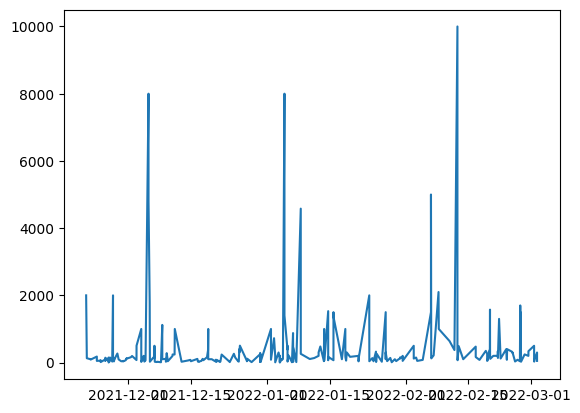

In [231]:
# Plotting (How he spent his money)
import matplotlib.pyplot as plt
plt.plot(df['Date'], df['INR'])

In [233]:
# day name wise bar chart

df['day_name'] = df['Date'].dt.day_name()

df.head()

,Date,Account,Category,Subcategory,Note,INR,Income/Expense,Note.1,Amount,Currency,Account.1,day_name
0,2022-03-02 10:11:00,CUB - online payment,Food,NaN,Brownie,50.0,Expense,NaN,50.0,INR,50.0,Wednesday
1,2022-03-02 10:11:00,CUB - online payment,Other,NaN,To lended people,300.0,Expense,NaN,300.0,INR,300.0,Wednesday
2,2022-03-01 19:50:00,CUB - online payment,Food,NaN,Dinner,78.0,Expense,NaN,78.0,INR,78.0,Tuesday
3,2022-03-01 18:56:00,CUB - online payment,Transportation,NaN,Metro,30.0,Expense,NaN,30.0,INR,30.0,Tuesday
4,2022-03-01 18:22:00,CUB - online payment,Food,NaN,Snacks,67.0,Expense,NaN,67.0,INR,67.0,Tuesday


<Axes: xlabel='day_name'>

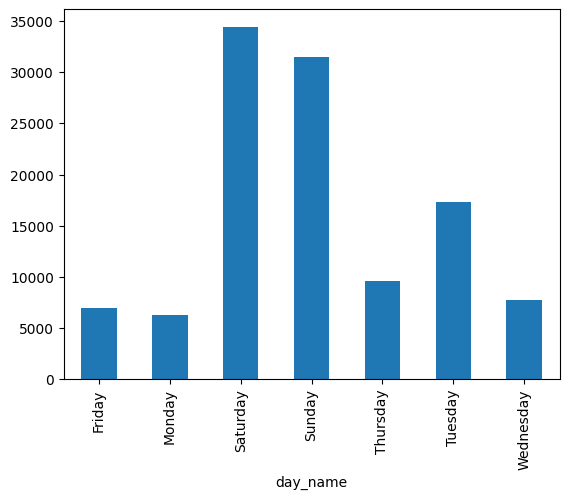

In [236]:
df.groupby('day_name')['INR'].sum().plot(kind='bar')

In [238]:
df['month_name'] = df['Date'].dt.month_name()
df

,Date,Account,Category,Subcategory,Note,INR,Income/Expense,Note.1,Amount,Currency,Account.1,day_name,month_name
0,2022-03-02 10:11:00,CUB - online payment,Food,NaN,Brownie,50.0,Expense,NaN,50.0,INR,50.0,Wednesday,March
1,2022-03-02 10:11:00,CUB - online payment,Other,NaN,To lended people,300.0,Expense,NaN,300.0,INR,300.0,Wednesday,March
2,2022-03-01 19:50:00,CUB - online payment,Food,NaN,Dinner,78.0,Expense,NaN,78.0,INR,78.0,Tuesday,March
3,2022-03-01 18:56:00,CUB - online payment,Transportation,NaN,Metro,30.0,Expense,NaN,30.0,INR,30.0,Tuesday,March
4,2022-03-01 18:22:00,CUB - online payment,Food,NaN,Snacks,67.0,Expense,NaN,67.0,INR,67.0,Tuesday,March
...,...,...,...,...,...,...,...,...,...,...,...,...,...
272,2021-11-22 14:16:00,CUB - online payment,Food,NaN,Dinner,90.0,Expense,NaN,90.0,INR,90.0,Monday,November
273,2021-11-22 14:16:00,CUB - online payment,Food,NaN,Lunch with company,97.0,Expense,NaN,97.0,INR,97.0,Monday,November
274,2021-11-21 17:07:00,CUB - online payment,Transportation,NaN,Rapido,130.0,Expense,NaN,130.0,INR,130.0,Sunday,November
275,2021-11-21 15:50:00,CUB - online payment,Food,NaN,Lunch,875.0,Expense,NaN,875.0,INR,875.0,Sunday,November


<Axes: xlabel='month_name'>

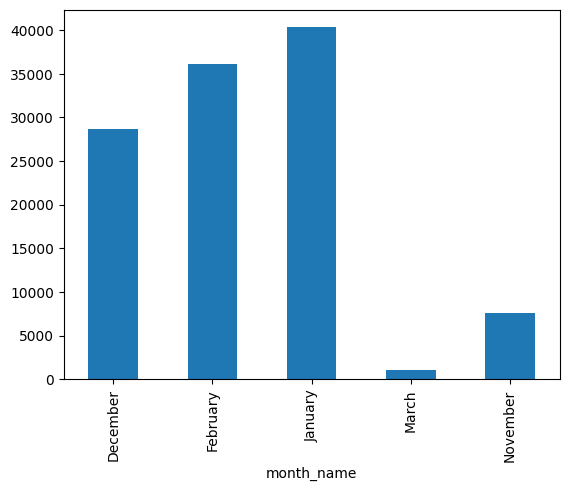

In [240]:
df.groupby('month_name')['INR'].sum().plot(kind='bar')